# 🔬 Quantum Tunneling Simulation: VQE + Trotter/SOFT

## Proyek Magang — Tautomerisasi Asam Amino

---

### 📋 Pipeline Lengkap:

```
STEP 1 → Install & Import Library
STEP 2 → Setup Geometri H₂O
STEP 3 → VQE untuk satu geometri (validasi)
STEP 4 → Scan PES: VQE di banyak geometri → dapat V(x)
STEP 5 → Plot PES hasil VQE
STEP 6 → Setup Wavefunction Awal (Gaussian)
STEP 7 → Trotter/SOFT: Evolusi Wavefunction
STEP 8 → Hitung Probabilitas Tunneling
STEP 9 → Plot Hasil Akhir (Benchmarking)
```

### 🧪 Molekul: H₂O
### ⚛️  Reaction Coordinate: jarak O-H (saat H menjauhi O)
### 🎯 Tujuan: Hitung probabilitas proton tunneling melewati barrier potensial

---
## STEP 1: Install & Import Library

Kita butuh beberapa library:
- **PySCF**: menghitung Hamiltonian molekul secara klasik (HF & FCI)
- **Qiskit Nature**: mengkonversi Hamiltonian ke format qubit untuk VQE
- **Qiskit Algorithms**: menjalankan VQE
- **NumPy & Matplotlib**: komputasi numerik dan visualisasi

In [1]:
# ============================================================
# IMPORT SEMUA LIBRARY
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.gridspec import GridSpec
import warnings
warnings.filterwarnings('ignore')

# --- Quantum Chemistry (klasik) ---
from pyscf import gto, scf, fci

# --- Qiskit: konversi ke qubit Hamiltonian ---
from qiskit_nature.second_q.drivers import PySCFDriver
from qiskit_nature.second_q.mappers import ParityMapper
from qiskit_nature.units import DistanceUnit
from qiskit_nature.second_q.circuit.library import UCCSD, HartreeFock

# --- Qiskit: VQE ---
from qiskit_algorithms import VQE
from qiskit_algorithms.optimizers import SLSQP
from qiskit_algorithms.utils import algorithm_globals
from qiskit.primitives import StatevectorEstimator as Estimator

# Set random seed supaya hasil reproducible
algorithm_globals.random_seed = 42
np.random.seed(42)

print('✅ Semua library berhasil diimport!')

✅ Semua library berhasil diimport!


---
## STEP 2: Setup Geometri H₂O

Kita definisikan fungsi untuk membuat geometri H₂O dengan O-H bond length yang bisa divariasikan.

```
Struktur H₂O:

    H           H
     \         /
      O   →  sudut 104.5°
     /
    H

Reaction coordinate = r(O-H)
Kita akan stretch satu O-H dari 0.7 Å sampai 2.5 Å
```

> **Mengapa 0.7 - 2.5 Å?**
> - r_eq (equilibrium) = 0.96 Å → ini titik minimum PES (sumur)
> - < 0.7 Å → terlalu dekat, energi sangat tinggi (tidak realistis)
> - > 2.5 Å → bond sudah hampir putus (dissosiasi)

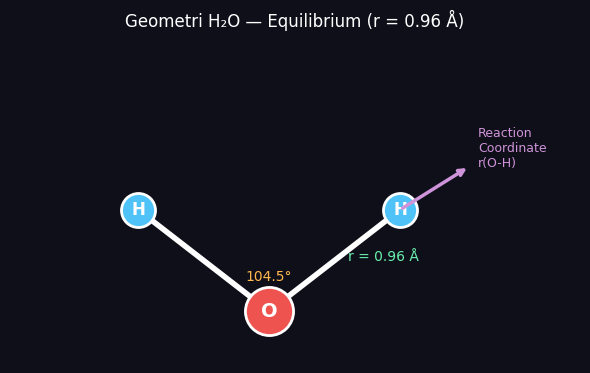

✅ Geometri H₂O berhasil dibuat!
   O  : (0.0, 0.0, 0.0)
   H1 : (0.759, 0.588, 0)
   H2 : (-0.759, 0.588, 0)


In [ ]:
# ============================================================
# FUNGSI: Build geometri H₂O
# ============================================================

def build_h2o_geometry(r_OH):
    """
    Buat geometri H₂O dengan O-H bond length = r_OH (Angstrom)
    
    Parameter:
        r_OH : float — panjang bond O-H dalam Angstrom
    
    Return:
        geometry : list — daftar (atom, koordinat) untuk PySCF
    """
    # Sudut H-O-H = 104.5 derajat (dari eksperimen)
    angle_deg  = 104.5
    angle_rad  = angle_deg * np.pi / 180
    half_angle = angle_rad / 2

    # Posisi atom H (O ada di origin)
    H1_x =  r_OH * np.sin(half_angle)   # H kanan
    H1_y =  r_OH * np.cos(half_angle)
    H2_x = -r_OH * np.sin(half_angle)   # H kiri
    H2_y =  r_OH * np.cos(half_angle)

    return [
        ("O", (0.0,   0.0,   0.0)),   # Oksigen di origin
        ("H", (H1_x,  H1_y,  0.0)),  # Hidrogen kanan
        ("H", (H2_x,  H2_y,  0.0)),  # Hidrogen kiri
    ]

# --- Visualisasi geometri equilibrium ---
r_eq = 0.96  # Angstrom (dari literatur/NIST)
geo  = build_h2o_geometry(r_eq)

fig, ax = plt.subplots(1, 1, figsize=(6, 5))
ax.set_facecolor('#1a1a2e')
fig.patch.set_facecolor('#0f0f1a')

O_pos  = np.array(geo[0][1][:2])
H1_pos = np.array(geo[1][1][:2])
H2_pos = np.array(geo[2][1][:2])

# Gambar bond O-H
for H_pos in [H1_pos, H2_pos]:
    ax.plot([O_pos[0], H_pos[0]], [O_pos[1], H_pos[1]],
            'w-', linewidth=4, zorder=1)

# Gambar atom
ax.scatter(*O_pos,  s=1200, color='#ef5350', zorder=3, edgecolors='white', linewidth=2)
ax.scatter(*H1_pos, s=600,  color='#4fc3f7', zorder=3, edgecolors='white', linewidth=2)
ax.scatter(*H2_pos, s=600,  color='#4fc3f7', zorder=3, edgecolors='white', linewidth=2)

# Label
ax.text(*O_pos,  'O',  ha='center', va='center', color='white', fontweight='bold', fontsize=14)
ax.text(*H1_pos, 'H',  ha='center', va='center', color='white', fontweight='bold', fontsize=12)
ax.text(*H2_pos, 'H',  ha='center', va='center', color='white', fontweight='bold', fontsize=12)

# Anotasi
mid = (O_pos + H1_pos) / 2
ax.text(mid[0]+0.08, mid[1], f'r = {r_eq} Å', color='#69f0ae', fontsize=10)
ax.text(0, 0.18, '104.5°', color='#ffb74d', fontsize=10, ha='center')

# Arrow: reaction coordinate
ax.annotate('', xy=(H1_pos[0]+0.4, H1_pos[1]+0.25),
            xytext=(H1_pos),
            arrowprops=dict(arrowstyle='->', color='#ce93d8', lw=2.5))
ax.text(H1_pos[0]+0.45, H1_pos[1]+0.25,
        'Reaction\nCoordinate\nr(O-H)', color='#ce93d8', fontsize=9)

ax.set_title('Geometri H₂O — Equilibrium (r = 0.96 Å)', color='white', fontsize=12)
ax.set_xlim(-1.5, 1.8)
ax.set_ylim(-0.3, 1.6)
ax.set_aspect('equal')
ax.axis('off')

plt.tight_layout()
plt.show()
print(f'✅ Geometri H₂O berhasil dibuat!')
print(f'   O  : {geo[0][1]}')
print(f'   H1 : ({geo[1][1][0]:.3f}, {geo[1][1][1]:.3f}, 0)')
print(f'   H2 : ({geo[2][1][0]:.3f}, {geo[2][1][1]:.3f}, 0)')

---
## STEP 3: VQE untuk Satu Geometri (Validasi)

Sebelum scan banyak titik, kita validasi dulu VQE untuk **satu geometri** (r = 0.96 Å).

```
Alur VQE:

Geometri H₂O
     ↓
PySCF → build Hamiltonian elektronik
     ↓
Born-Oppenheimer → pisahkan nukleus & elektron
     ↓
Hartree-Fock → wavefunction referensi |HF⟩
     ↓
Qiskit Nature → konversi ke qubit Hamiltonian
     ↓
UCCSD Ansatz → circuit parametrik di atas |HF⟩
     ↓
VQE → optimasi parameter θ → E_min
     ↓
Bandingkan dengan FCI (exact)
```

In [ ]:
# ============================================================
# FUNGSI UTAMA: Jalankan VQE untuk satu geometri H₂O
# ============================================================

def run_vqe_h2o(r_OH, verbose=True):
    """
    Hitung ground state energy H₂O dengan VQE.
    
    Parameter:
        r_OH    : float — panjang bond O-H (Angstrom)
        verbose : bool  — print info atau tidak
    
    Return:
        E_HF          : float — energi Hartree-Fock
        E_VQE         : float — energi VQE
        E_FCI         : float — energi FCI (exact)
        energy_history: list  — konvergensi VQE
    """
    geo = build_h2o_geometry(r_OH)

    # --------------------------------------------------
    # BAGIAN A: PySCF — Hartree-Fock & FCI
    # --------------------------------------------------
    # Build molekul
    mol = gto.Mole()
    mol.atom   = geo
    mol.basis  = 'sto-3g'    # basis set minimal
    mol.charge = 0            # molekul netral
    mol.spin   = 0            # singlet
    mol.unit   = 'Angstrom'
    mol.verbose = 0
    mol.build()

    # Hartree-Fock: mean field approximation
    # Ini jadi referensi awal dan initial state VQE
    mf = scf.RHF(mol)
    mf.verbose = 0
    mf.run()
    E_HF = mf.e_tot

    # FCI: exact (untuk molekul kecil)
    # Ini jadi ground truth kita
    try:
        cisolver = fci.FCI(mf)
        cisolver.verbose = 0
        E_FCI, _ = cisolver.kernel()
    except:
        E_FCI = None

    # --------------------------------------------------
    # BAGIAN B: Qiskit — Convert ke Qubit Hamiltonian
    # --------------------------------------------------
    atom_str = (f"O 0 0 0; "
                f"H {geo[1][1][0]:.4f} {geo[1][1][1]:.4f} 0; "
                f"H {geo[2][1][0]:.4f} {geo[2][1][1]:.4f} 0")

    driver  = PySCFDriver(
        atom=atom_str, basis="sto-3g",
        charge=0, spin=0,
        unit=DistanceUnit.ANGSTROM
    )
    problem = driver.run()

    # ParityMapper: konversi fermionic → qubit operator
    # (dengan 2-qubit reduction → lebih efisien)
    mapper   = ParityMapper(num_particles=problem.num_particles)
    qubit_op = mapper.map(problem.second_q_ops()[0])

    # --------------------------------------------------
    # BAGIAN C: Setup Ansatz UCCSD
    # --------------------------------------------------
    # Initial state = Hartree-Fock state
    hf_state = HartreeFock(
        num_spatial_orbitals = problem.num_spatial_orbitals,
        num_particles        = problem.num_particles,
        qubit_mapper         = mapper,
    )

    # UCCSD ansatz: tambahkan excitations di atas |HF⟩
    # Single excitation: 1 elektron pindah orbital
    # Double excitation: 2 elektron pindah orbital
    ansatz = UCCSD(
        num_spatial_orbitals = problem.num_spatial_orbitals,
        num_particles        = problem.num_particles,
        qubit_mapper         = mapper,
        initial_state        = hf_state,
    )

    # --------------------------------------------------
    # BAGIAN D: Jalankan VQE
    # --------------------------------------------------
    # Simpan history konvergensi
    energy_history = []
    def callback(eval_count, params, energy, meta):
        energy_history.append(energy)

    vqe = VQE(
        estimator     = Estimator(),
        ansatz        = ansatz,
        optimizer     = SLSQP(maxiter=300),
        initial_point = np.zeros(ansatz.num_parameters),
        callback      = callback,
    )

    result = vqe.compute_minimum_eigenvalue(qubit_op)

    # Tambahkan nuclear repulsion energy
    # (VQE hanya hitung energi elektronik)
    E_VQE = result.eigenvalue.real + problem.nuclear_repulsion_energy

    if verbose:
        print(f'  r(O-H) = {r_OH:.2f} Å')
        print(f'  E_HF   = {E_HF:.6f} Ha')
        print(f'  E_VQE  = {E_VQE:.6f} Ha')
        print(f'  E_FCI  = {E_FCI:.6f} Ha')
        if E_FCI:
            err = abs(E_VQE - E_FCI) * 1000
            status = '✅' if err < 1.6 else '⚠️'
            print(f'  Error  = {err:.4f} mHa {status}')

    return E_HF, E_VQE, E_FCI, energy_history, problem

print('✅ Fungsi run_vqe_h2o() siap digunakan!')

✅ Fungsi run_vqe_h2o() siap digunakan!


In [4]:
# ============================================================
# JALANKAN VQE untuk satu geometri: r = 0.96 Å (equilibrium)
# ============================================================
# Ini untuk validasi — pastikan VQE bekerja sebelum scan banyak titik

print('Menjalankan VQE H₂O di r = 0.96 Å (equilibrium)...')
print('=' * 50)

E_HF_eq, E_VQE_eq, E_FCI_eq, history_eq, problem_eq = run_vqe_h2o(r_eq, verbose=True)

print('=' * 50)
print('✅ VQE berhasil!')

Menjalankan VQE H₂O di r = 0.96 Å (equilibrium)...


KeyboardInterrupt: 

In [ ]:
# ============================================================
# PLOT: Konvergensi VQE + Perbandingan Energi
# ============================================================
# Grafik ini menunjukkan:
# - Kiri: bagaimana energi turun selama optimasi VQE
# - Kanan: perbandingan HF vs VQE vs FCI

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.patch.set_facecolor('#0f0f1a')

DARK = '#1a1a2e'; BLUE = '#4fc3f7'
GREEN = '#69f0ae'; ORANGE = '#ffb74d'
RED = '#ef5350'; PURPLE = '#ce93d8'
WHITE = '#e0e0e0'; GRAY = '#555577'

def style(ax, title):
    ax.set_facecolor(DARK)
    ax.set_title(title, color=WHITE, fontsize=11, pad=10)
    ax.tick_params(colors=WHITE)
    ax.xaxis.label.set_color(WHITE)
    ax.yaxis.label.set_color(WHITE)
    for s in ax.spines.values(): s.set_edgecolor(GRAY)
    ax.grid(alpha=0.15, color=WHITE)

# --- KIRI: Konvergensi VQE ---
ax1 = axes[0]
style(ax1, f'Konvergensi VQE H₂O (r = {r_eq} Å)')

nrep = problem_eq.nuclear_repulsion_energy
iters = range(1, len(history_eq)+1)

ax1.plot(iters, history_eq, color=BLUE, lw=2, label='Energi tiap iterasi')
ax1.axhline(E_VQE_eq - nrep, color=GREEN,  ls='--', lw=2,
            label=f'VQE konvergen = {E_VQE_eq:.4f} Ha')
ax1.axhline(E_HF_eq  - nrep, color=ORANGE, ls=':',  lw=2,
            label=f'Hartree-Fock  = {E_HF_eq:.4f} Ha')
ax1.fill_between(iters,
    E_HF_eq - nrep, history_eq,
    alpha=0.1, color=GREEN, label='Korelasi elektron\nyang ditangkap VQE')

ax1.set_xlabel('Iterasi Optimizer (SLSQP)')
ax1.set_ylabel('Energi Elektronik (Ha)')
ax1.legend(facecolor='#0f0f1a', edgecolor=GRAY,
           labelcolor=WHITE, fontsize=8)

# Anotasi: HF tidak cukup!
ax1.annotate('HF tidak\nmenangkap\nkorelasi!',
    xy=(len(history_eq)//2, E_HF_eq - nrep),
    xytext=(len(history_eq)//3, E_HF_eq - nrep + 0.05),
    color=ORANGE, fontsize=8,
    arrowprops=dict(arrowstyle='->', color=ORANGE))

# --- KANAN: Perbandingan Energi ---
ax2 = axes[1]
style(ax2, 'Perbandingan Energi H₂O')

methods  = ['Hartree-\nFock', 'VQE\n(UCCSD)', 'FCI\n(Exact)']
energies = [E_HF_eq, E_VQE_eq, E_FCI_eq]
colors   = [ORANGE, BLUE, GREEN]

bars = ax2.bar(methods, energies, color=colors,
               alpha=0.8, edgecolor=WHITE, lw=1.2, width=0.5)
ax2.axhline(E_FCI_eq, color=GREEN, ls='--', alpha=0.4)

for bar, e in zip(bars, energies):
    ax2.text(bar.get_x() + bar.get_width()/2,
             e + 0.003, f'{e:.4f} Ha',
             ha='center', va='bottom', color=WHITE, fontsize=9)

# Anotasi error
err_mHa = abs(E_VQE_eq - E_FCI_eq) * 1000
ax2.text(0.5, -0.3,
    f'Error VQE vs FCI = {err_mHa:.4f} mHa\n'
    f'Chemical accuracy = 1.6 mHa\n'
    f'Status: {"✅ LULUS" if err_mHa < 1.6 else "⚠️ Belum lulus"}',
    transform=ax2.transAxes,
    ha='center', va='center',
    color=GREEN if err_mHa < 1.6 else RED,
    fontsize=10,
    bbox=dict(boxstyle='round', facecolor='#0f0f1a', edgecolor=GREEN, alpha=0.8))

ax2.set_ylabel('Total Energy (Hartree)')

fig.suptitle('Validasi VQE H₂O — Satu Geometri (r = 0.96 Å)',
             color=WHITE, fontsize=13, y=1.01)
plt.tight_layout()
plt.show()
print('✅ Validasi VQE selesai!')

---
## STEP 4: Scan PES — VQE di Banyak Geometri

Sekarang kita jalankan VQE untuk **setiap titik** di sepanjang reaction coordinate.

```
Untuk tiap r(O-H) dari 0.7 Å sampai 2.5 Å:
    → jalankan VQE
    → simpan E_VQE

Hasilnya: array (r, E) → PES!
```

> ⏱️ **Estimasi waktu**: ~15-30 menit (tergantung hardware)
> Karena tiap titik = 1x VQE dengan ratusan iterasi optimizer

In [ ]:
# ============================================================
# SCAN PES: VQE di banyak geometri
# ============================================================
# r_values = titik-titik reaction coordinate yang discan
# Δr = 0.1 Å (bisa diperhalus ke 0.05 Å untuk PES lebih smooth)

r_values = np.arange(0.7, 2.51, 0.1)  # 19 titik

print(f'Scan PES H₂O: {len(r_values)} titik')
print(f'r dari {r_values[0]:.1f} Å sampai {r_values[-1]:.1f} Å, Δr = 0.1 Å')
print('=' * 55)

E_HF_list  = []
E_VQE_list = []
E_FCI_list = []

for i, r in enumerate(r_values):
    print(f'[{i+1:2d}/{len(r_values)}] r = {r:.2f} Å ... ', end='', flush=True)
    try:
        E_HF, E_VQE, E_FCI, _, _ = run_vqe_h2o(r, verbose=False)
        E_HF_list.append(E_HF)
        E_VQE_list.append(E_VQE)
        E_FCI_list.append(E_FCI)
        print(f'E = {E_VQE:.5f} Ha ✓')
    except Exception as e:
        print(f'Error: {e}')
        E_HF_list.append(None)
        E_VQE_list.append(None)
        E_FCI_list.append(None)

# Filter titik yang gagal
valid = [(r, hf, vqe, fci_e)
         for r, hf, vqe, fci_e in zip(r_values, E_HF_list, E_VQE_list, E_FCI_list)
         if None not in (hf, vqe, fci_e)]

r_pes   = np.array([v[0] for v in valid])
E_HF_pes = np.array([v[1] for v in valid])
E_VQE_pes = np.array([v[2] for v in valid])
E_FCI_pes = np.array([v[3] for v in valid])

print('=' * 55)
print(f'✅ Scan selesai! {len(valid)}/{len(r_values)} titik berhasil.')
print(f'   E_min VQE = {np.min(E_VQE_pes):.5f} Ha di r = {r_pes[np.argmin(E_VQE_pes)]:.2f} Å')

---
## STEP 5: Plot PES Hasil VQE

PES inilah yang jadi **operator potensial V(x)** untuk Trotter!

```
x-axis : r(O-H) — reaction coordinate (Å)
y-axis : Ground state energy (Ha) dari VQE
```

> **Catatan**: Untuk H₂O biasa, PES-nya **single well** (satu sumur).
> Untuk tautomerisasi asam amino (Glisin), kita akan dapat **double well**!

In [ ]:
# ============================================================
# PLOT PES: Potential Energy Surface H₂O
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.patch.set_facecolor('#0f0f1a')

# --- KIRI: PES lengkap ---
ax1 = axes[0]
style(ax1, 'Potential Energy Surface H₂O\n(O-H Stretch)')

ax1.plot(r_pes, E_HF_pes,  color=ORANGE, lw=2, marker='o',
         ms=5, label='Hartree-Fock')
ax1.plot(r_pes, E_VQE_pes, color=BLUE,   lw=2.5, marker='s',
         ms=5, label='VQE (UCCSD)')
ax1.plot(r_pes, E_FCI_pes, color=GREEN,  lw=2, ls='--',
         marker='^', ms=5, label='FCI (Exact)')

# Tandai minimum
min_idx = np.argmin(E_VQE_pes)
ax1.scatter(r_pes[min_idx], E_VQE_pes[min_idx],
            s=200, color=RED, zorder=5,
            label=f'Minimum r={r_pes[min_idx]:.2f}Å')
ax1.axvline(r_pes[min_idx], color=RED, ls=':', alpha=0.5)

# Anotasi fisika
ax1.text(0.8,  E_VQE_pes[0]+0.1,
         'H terlalu\ndekat O\n(repulsif)',
         color='#ff8a80', fontsize=8, ha='center')
ax1.text(2.2, E_VQE_pes[-1]-0.15,
         'H menjauh\ndari O\n(dissosiasi)',
         color=PURPLE, fontsize=8, ha='center')
ax1.text(r_pes[min_idx], E_VQE_pes[min_idx]-0.1,
         f'Equilibrium\nr={r_pes[min_idx]:.2f}Å',
         color=RED, fontsize=8, ha='center', va='top')

ax1.set_xlabel('r(O-H) — Reaction Coordinate (Å)')
ax1.set_ylabel('Ground State Energy (Ha)')
ax1.legend(facecolor='#0f0f1a', edgecolor=GRAY, labelcolor=WHITE, fontsize=8)

# --- KANAN: V(x) yang akan dipakai Trotter ---
# Normalisasi PES supaya minimum = 0
ax2 = axes[1]
style(ax2, 'V(x) — Operator Potensial untuk Trotter\n(PES dinormalisasi, min = 0)')

V_x = E_VQE_pes - np.min(E_VQE_pes)  # shift supaya minimum = 0

ax2.plot(r_pes, V_x, color=BLUE, lw=2.5, marker='s', ms=5)
ax2.fill_between(r_pes, V_x, alpha=0.15, color=BLUE)

# Tandai tiap titik VQE
for r, v in zip(r_pes, V_x):
    ax2.axvline(r, color=GRAY, lw=0.5, alpha=0.4)

ax2.set_xlabel('r(O-H) = x_k (Å) — Reaction Coordinate')
ax2.set_ylabel('V(x_k) = E_VQE(r) - E_min (Ha)')

# Anotasi: tiap titik = satu VQE calculation
ax2.annotate('Tiap titik ini =\nsatu kalkulasi VQE',
    xy=(r_pes[3], V_x[3]),
    xytext=(r_pes[3]+0.3, V_x[3]+0.2),
    color=GREEN, fontsize=8,
    arrowprops=dict(arrowstyle='->', color=GREEN))

ax2.text(0.5, 0.92,
    f'Total titik: {len(r_pes)}\nΔr = 0.1 Å',
    transform=ax2.transAxes, ha='center',
    color=WHITE, fontsize=9,
    bbox=dict(boxstyle='round', facecolor='#0f0f1a',
              edgecolor=BLUE, alpha=0.8))

fig.suptitle('PES H₂O dari VQE → Ini yang Jadi Input Trotter!',
             color=WHITE, fontsize=13)
plt.tight_layout()
plt.show()
print('✅ PES berhasil diplot!')
print(f'   V(x) siap digunakan sebagai operator potensial di Trotter')

---
## STEP 6: Setup Wavefunction Awal (Gaussian)

Wavefunction awal adalah **Gaussian yang terlokalisasi di sumur potensial**.

```
ψ₀(x) = exp(-(x - x₀)² / 2σ²)

x₀ = posisi minimum PES (titik equilibrium)
σ  = lebar Gaussian (seberapa tersebar partikel di awal)
```

> **Mengapa Gaussian?**
> Ground state harmonic oscillator berbentuk Gaussian.
> Di sekitar minimum PES, potensial ≈ parabola (harmonic).
> Jadi Gaussian adalah pilihan yang **physically justified**!

In [ ]:
# ============================================================
# SETUP WAVEFUNCTION AWAL (GAUSSIAN)
# ============================================================

# Grid posisi = reaction coordinate dari PES
x = r_pes.copy()         # posisi x_k dalam Angstrom
dx = x[1] - x[0]        # Δx

# Gaussian di posisi minimum PES
x0    = r_pes[np.argmin(E_VQE_pes)]  # pusat = minimum PES
sigma = 0.15                           # lebar (dalam Angstrom)

# Wavefunction awal
psi0 = np.exp(-(x - x0)**2 / (2 * sigma**2))
psi0 = psi0 / np.sqrt(np.sum(np.abs(psi0)**2) * dx)  # normalisasi

# Probabilitas awal
prob0 = np.abs(psi0)**2

# Operator potensial V(x) dari PES VQE
V_x = E_VQE_pes - np.min(E_VQE_pes)

# --- PLOT ---
fig, ax = plt.subplots(figsize=(10, 5))
fig.patch.set_facecolor('#0f0f1a')
style(ax, 'Wavefunction Awal ψ₀(x) — Gaussian di Minimum PES')

# Plot V(x) sebagai background (scaled)
V_scaled = V_x / V_x.max() * prob0.max() * 0.8
ax.fill_between(x, V_scaled, alpha=0.2, color=GREEN, label='V(x) PES (scaled)')
ax.plot(x, V_scaled, color=GREEN, lw=1.5, alpha=0.7)

# Plot wavefunction awal
ax.fill_between(x, prob0, alpha=0.4, color=BLUE)
ax.plot(x, prob0, color=BLUE, lw=2.5, label=f'|ψ₀(x)|² (Gaussian, σ={sigma}Å)')

# Tandai pusat Gaussian
ax.axvline(x0, color=RED, ls='--', lw=2, label=f'x₀ = {x0:.2f} Å (minimum PES)')

# Anotasi
ax.text(x0, prob0.max()*1.05,
        f'Pusat Gaussian\nx₀ = {x0:.2f} Å',
        ha='center', color=RED, fontsize=9)

# Normalisasi check
norm = np.sum(prob0) * dx
ax.text(0.98, 0.95, f'Normalisasi = {norm:.6f}\n(harus = 1.0)',
        transform=ax.transAxes, ha='right', va='top',
        color=WHITE, fontsize=9,
        bbox=dict(boxstyle='round', facecolor='#0f0f1a', edgecolor=GRAY))

ax.set_xlabel('r(O-H) = x (Å)')
ax.set_ylabel('Probabilitas |ψ(x)|²')
ax.legend(facecolor='#0f0f1a', edgecolor=GRAY, labelcolor=WHITE)

plt.tight_layout()
plt.show()

print(f'✅ Wavefunction awal siap!')
print(f'   Pusat x₀  = {x0:.2f} Å')
print(f'   Lebar σ   = {sigma:.2f} Å')
print(f'   Normalisasi = {norm:.6f} (harus = 1)')

---
## STEP 7: Trotter/SOFT — Evolusi Wavefunction

Sekarang kita evolusikan wavefunction menggunakan **Split Operator Fourier Transform (SOFT)**.

```
Satu Trotter Step (Orde 2 — lebih akurat):

ψ  →  e^{-iV(x)δt/2}  →  QFT  →  e^{-iT(k)δt}  →  IQFT  →  e^{-iV(x)δt/2}  →  ψ_baru
       ↑                                ↑
  Apply V(x) dari PES VQE        Apply T(k) di k-space
  ke semua titik SEKALIGUS       ke semua k SEKALIGUS
```

> **V(x)** → dari PES VQE yang sudah kita hitung di Step 4
> **T(k)** → operator kinetik = ℏ²k²/2m (massa proton)

In [ ]:
# ============================================================
# TROTTER/SOFT: Evolusi Wavefunction
# ============================================================

# --- Parameter Trotter ---
m_proton  = 1836.15    # massa proton (satuan atomik, relative to electron)
dt        = 0.5        # time step (satuan atomik)
n_steps   = 200        # jumlah Trotter steps

# Konversi dx ke satuan atomik (1 Angstrom = 1.8897 bohr)
bohr_per_ang = 1.8897
dx_au = dx * bohr_per_ang
x_au  = x  * bohr_per_ang

# --- Grid momentum (k-space untuk QFT) ---
N = len(x)
k = np.fft.fftfreq(N, d=dx_au) * 2 * np.pi  # momentum grid

# --- Operator Kinetik: T(k) = ℏ²k²/2m ---
T_k = k**2 / (2 * m_proton)

# --- Operator Potensial: V(x) dari PES VQE ---
# Konversi ke satuan atomik (1 Ha = 1 a.u. energy, sudah benar)
V_au = V_x.copy()  # V(x) dari PES VQE (sudah dalam Hartree)

# --- Pre-compute operator eksponensial (SEKALI SAJA!) ---
# Ini yang diapply ke SEMUA titik sekaligus di tiap step
exp_V_half = np.exp(-1j * V_au * dt / 2)   # e^{-iV(x)δt/2}
exp_T      = np.exp(-1j * T_k * dt)         # e^{-iT(k)δt}

def trotter_step(psi):
    """
    Satu Trotter step orde 2 (Strang splitting):
    e^{-iHδt} ≈ e^{-iV δt/2} · e^{-iT δt} · e^{-iV δt/2}

    Tiap operasi diapply ke SEMUA titik SEKALIGUS!
    """
    # 1. Apply V(x) setengah step — semua x_k sekaligus!
    psi = exp_V_half * psi

    # 2. QFT: pindah ke ruang momentum (k-space)
    psi_k = np.fft.fft(psi)

    # 3. Apply T(k) — semua k sekaligus!
    psi_k = exp_T * psi_k

    # 4. IQFT: balik ke ruang posisi (x-space)
    psi = np.fft.ifft(psi_k)

    # 5. Apply V(x) setengah step lagi
    psi = exp_V_half * psi

    return psi

# --- Jalankan evolusi! ---
psi = psi0.astype(complex).copy()  # wavefunction awal

# Simpan snapshot untuk visualisasi
snapshots = [(0, np.abs(psi)**2)]
snap_steps = [n_steps//4, n_steps//2, 3*n_steps//4, n_steps]
prob_right_history = [np.sum(np.abs(psi)**2 * (x > x0)) * dx]

print(f'Menjalankan {n_steps} Trotter steps...')
print(f'  dt = {dt} a.u., massa proton = {m_proton} me')

for step in range(1, n_steps + 1):
    psi = trotter_step(psi)

    # Hitung probabilitas di kanan x0 (sudah melewati minimum)
    prob_right = np.sum(np.abs(psi)**2 * (x > x0)) * dx
    prob_right_history.append(prob_right)

    if step in snap_steps:
        snapshots.append((step * dt, np.abs(psi)**2))
        print(f'  Step {step:4d}/{n_steps} — P(x>x0) = {prob_right:.4f}')

psi_final = psi.copy()
print(f'\n✅ Trotter selesai!')
print(f'   Normalisasi akhir = {np.sum(np.abs(psi_final)**2)*dx:.6f}')

---
## STEP 8: Hitung Probabilitas Tunneling

```
P_tunneling = Σ |ψ(x, t)|² · dx
              x > x_barrier

= jumlah probabilitas wavefunction
  yang sudah melewati barrier potensial
```

> Untuk H₂O (single well), tunneling artinya proton H berhasil
> menjauhi O melewati barrier dissosiasi.

In [ ]:
# ============================================================
# HITUNG PROBABILITAS TUNNELING
# ============================================================

# Tentukan barrier region
# Untuk H₂O: x_barrier = posisi setelah minimum PES
x_barrier = x0 + 0.5  # 0.5 Å setelah equilibrium

# Probabilitas awal dan akhir
prob_initial  = np.abs(psi0)**2
prob_final    = np.abs(psi_final)**2

P_left_initial  = np.sum(prob_initial[x <= x_barrier]) * dx
P_right_initial = np.sum(prob_initial[x >  x_barrier]) * dx
P_left_final    = np.sum(prob_final[x <= x_barrier]) * dx
P_right_final   = np.sum(prob_final[x >  x_barrier]) * dx

P_tunneling = P_right_final  # ini probabilitas tunneling!

print('=' * 50)
print('HASIL PROBABILITAS TUNNELING:')
print('=' * 50)
print(f'  Barrier di x = {x_barrier:.2f} Å')
print(f'')
print(f'  --- Distribusi AWAL ---')
print(f'  P(x ≤ barrier) = {P_left_initial:.4f} ({P_left_initial*100:.2f}%)')
print(f'  P(x > barrier) = {P_right_initial:.4f} ({P_right_initial*100:.2f}%)')
print(f'')
print(f'  --- Distribusi AKHIR ---')
print(f'  P(x ≤ barrier) = {P_left_final:.4f} ({P_left_final*100:.2f}%)')
print(f'  P(x > barrier) = {P_right_final:.4f} ({P_right_final*100:.2f}%)')
print(f'')
print(f'  PROBABILITAS TUNNELING = {P_tunneling:.4f}')
print(f'  = {P_tunneling*100:.2f}% proton berhasil melewati barrier')
print('=' * 50)

---
## STEP 9: Plot Hasil Akhir

Plot lengkap menunjukkan:
1. PES dari VQE + Wavefunction awal & akhir
2. Evolusi wavefunction dari waktu ke waktu
3. Probabilitas tunneling vs waktu

In [ ]:
# ============================================================
# PLOT HASIL AKHIR LENGKAP
# ============================================================

fig = plt.figure(figsize=(16, 14))
fig.patch.set_facecolor('#0f0f1a')
gs = GridSpec(3, 2, figure=fig, hspace=0.45, wspace=0.35)

snap_colors = [BLUE, '#00bcd4', GREEN, ORANGE, RED]
snap_labels = ['Awal (t=0)',
               f't={snap_steps[0]*dt:.0f} a.u.',
               f't={snap_steps[1]*dt:.0f} a.u.',
               f't={snap_steps[2]*dt:.0f} a.u.',
               f'Akhir (t={n_steps*dt:.0f} a.u.)']

# --- Grafik 1: PES + Initial & Final Wavefunction ---
ax1 = fig.add_subplot(gs[0, :])
style(ax1, 'PES H₂O (dari VQE) + Wavefunction Awal & Akhir\n'
           '[Seperti gambar di paper tunneling yang kalian upload!]')

# PES
ax1.plot(x, V_x, 'g-', lw=3, label='PES V(x) dari VQE', alpha=0.8)
ax1.fill_between(x, V_x, alpha=0.1, color=GREEN)

# Scale wavefunction supaya keliatan di atas PES
scale = V_x.max() * 0.6 / prob_initial.max()

# Initial wavefunction
ax1.plot(x, prob_initial * scale, color=BLUE, lw=2.5,
         label=f'|ψ₀|² (awal, P_right={P_right_initial:.3f})', ls='--')

# Final wavefunction
ax1.plot(x, prob_final * scale, color=RED, lw=2.5,
         label=f'|ψ_final|² (akhir, P_right={P_right_final:.3f})')
ax1.fill_between(x, prob_final * scale,
                 where=(x > x_barrier),
                 alpha=0.3, color=RED, label=f'Tunneled! P={P_tunneling:.3f}')

# Barrier line
ax1.axvline(x_barrier, color=ORANGE, ls=':', lw=2, label=f'Barrier x={x_barrier:.1f}Å')

ax1.set_xlabel('r(O-H) — Reaction Coordinate (Å)', fontsize=11)
ax1.set_ylabel('Energi / Probabilitas (a.u.)', fontsize=11)
ax1.legend(facecolor='#0f0f1a', edgecolor=GRAY,
           labelcolor=WHITE, fontsize=9, ncol=2)

# --- Grafik 2: Evolusi Wavefunction ---
ax2 = fig.add_subplot(gs[1, :])
style(ax2, 'Evolusi Wavefunction |ψ(x,t)|² dari Waktu ke Waktu')

V_bg = V_x / V_x.max() * max(s[1].max() for s in snapshots) * 0.5
ax2.plot(x, V_bg, 'g-', lw=1.5, alpha=0.4, label='PES (scaled)')

for (t_snap, prob_snap), color, label in zip(snapshots, snap_colors, snap_labels):
    lw = 2.5 if label in ['Awal (t=0)', snap_labels[-1]] else 1.5
    alpha = 1.0 if label in ['Awal (t=0)', snap_labels[-1]] else 0.6
    ax2.plot(x, prob_snap, color=color, lw=lw, alpha=alpha, label=label)

ax2.axvline(x_barrier, color=ORANGE, ls=':', lw=2, label=f'Barrier')
ax2.set_xlabel('r(O-H) (Å)')
ax2.set_ylabel('|ψ(x,t)|²')
ax2.legend(facecolor='#0f0f1a', edgecolor=GRAY, labelcolor=WHITE,
           fontsize=9, ncol=3)

# --- Grafik 3: Probabilitas Tunneling vs Waktu ---
ax3 = fig.add_subplot(gs[2, 0])
style(ax3, 'Probabilitas Tunneling vs Waktu')

time_axis = np.arange(len(prob_right_history)) * dt
ax3.plot(time_axis, prob_right_history, color=PURPLE, lw=2)
ax3.fill_between(time_axis, prob_right_history, alpha=0.2, color=PURPLE)
ax3.axhline(P_tunneling, color=RED, ls='--', lw=2,
            label=f'P_final = {P_tunneling:.4f}')

ax3.set_xlabel('Waktu (a.u.)')
ax3.set_ylabel('P(x > barrier)')
ax3.legend(facecolor='#0f0f1a', edgecolor=GRAY, labelcolor=WHITE)

# --- Grafik 4: Ringkasan Hasil ---
ax4 = fig.add_subplot(gs[2, 1])
style(ax4, 'Ringkasan Distribusi Probabilitas')

regions = ['Kiri barrier\n(awal)', 'Kanan barrier\n(awal)',
           'Kiri barrier\n(akhir)', 'Kanan barrier\n(akhir)']
probs   = [P_left_initial, P_right_initial, P_left_final, P_right_final]
clrs    = [BLUE, '#1a6b8a', GREEN, RED]

bars = ax4.bar(regions, probs, color=clrs, alpha=0.8,
               edgecolor=WHITE, lw=1.2)
for bar, p in zip(bars, probs):
    ax4.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.005,
             f'{p:.3f}\n({p*100:.1f}%)',
             ha='center', va='bottom', color=WHITE, fontsize=9)

ax4.set_ylabel('Probabilitas')
ax4.set_ylim(0, 1.1)

# Box kesimpulan
ax4.text(0.5, 0.5,
    f'🎯 HASIL TUNNELING\n\n'
    f'P_tunneling = {P_tunneling:.4f}\n'
    f'= {P_tunneling*100:.2f}% proton\nberhasil melewati barrier',
    transform=ax4.transAxes,
    ha='center', va='center',
    color=WHITE, fontsize=10,
    bbox=dict(boxstyle='round,pad=0.5',
              facecolor='#0f0f1a',
              edgecolor=RED, alpha=0.9, lw=2))

fig.suptitle('Hasil Simulasi Quantum Tunneling H₂O\nVQE + Trotter/SOFT',
             color=WHITE, fontsize=14, y=0.99)
plt.savefig('vqe_tunneling_result.png', dpi=150,
            bbox_inches='tight', facecolor='#0f0f1a')
plt.show()
print('✅ Plot hasil akhir selesai!')
print('   File disimpan: vqe_tunneling_result.png')

---
## ✅ Selesai! Apa Selanjutnya?

```
SUDAH SELESAI:
✅ VQE H₂O → PES
✅ Trotter/SOFT → evolusi wavefunction
✅ Probabilitas tunneling

LANGKAH SELANJUTNYA:
⏳ 1. Ganti H₂O dengan Glisin (asam amino)
      → reaction coordinate ξ = r(O-H) - r(N-H)
      → PES → double well!

⏳ 2. Quantum circuit Trotter (Qiskit)
      → translate Trotter ke quantum gates
      → jalankan di Qiskit Aer simulator

⏳ 3. Real hardware
      → IBM Quantum / IonQ
      → bandingkan dengan classical Trotter

⏳ 4. Benchmarking
      → Classical vs Quantum Simulator vs Real HW
      → Analisis error dan noise
```